In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list the files in the input directory

import os
print(os.listdir("./"))

# Any results you write to the current directory are saved as output.

['2021-08-30_amzn.png', 'AAPL.csv', 'AMZN.csv', 'GOOG.csv', 'IBM.csv', 'model_amzn.pth', 'Stocks_All.csv', 'Stocks_Pred_1.ipynb', 'Stocks_Pred_2.ipynb', 'sum.csv', 'TSLA.csv']


In [2]:
# importing libraries
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, GRU, Bidirectional

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import math
import warnings

#from keras.optimizers import SGD (Now is ternsorflow.keras.optimizers)
plt.style.use("fivethirtyeight")
warnings.filterwarnings("ignore")

In [3]:
# function which plots ibm stock prices: real and predicted both
def plot_predictions(test, predicted):
    plt.plot(test, color="red", label="real IBM stock price")
    plt.plot(predicted, color="blue", label="predicted stock price")
    plt.title("IBM stock price prediction")
    plt.xlabel("time")
    plt.ylabel("IBM stock price")
    plt.legend()
    plt.show()

In [4]:
# function which calculates root mean squared error
def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("the root mean squared error is : {}.".format(rmse))

In [5]:
data = pd.read_csv("IBM.csv", index_col='Date', parse_dates=["Date"])
data.shape

(1282, 6)

In [6]:
data.head(5)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2016-08-30,159.759995,160.149994,158.809998,159.399994,127.268356,1813300
2016-08-31,159.660004,159.660004,158.259995,158.880005,126.853180,2323600
2016-09-01,158.320007,159.619995,158.100006,159.539993,127.380173,2358400
2016-09-02,159.880005,160.570007,159.149994,159.550003,127.388161,2315400
2016-09-06,159.880005,160.860001,159.110001,160.350006,128.026855,2994100


In [7]:
train = data["2015":"2020"].iloc[:,1:2].values
test = data["2021":].iloc[:,1:2].values

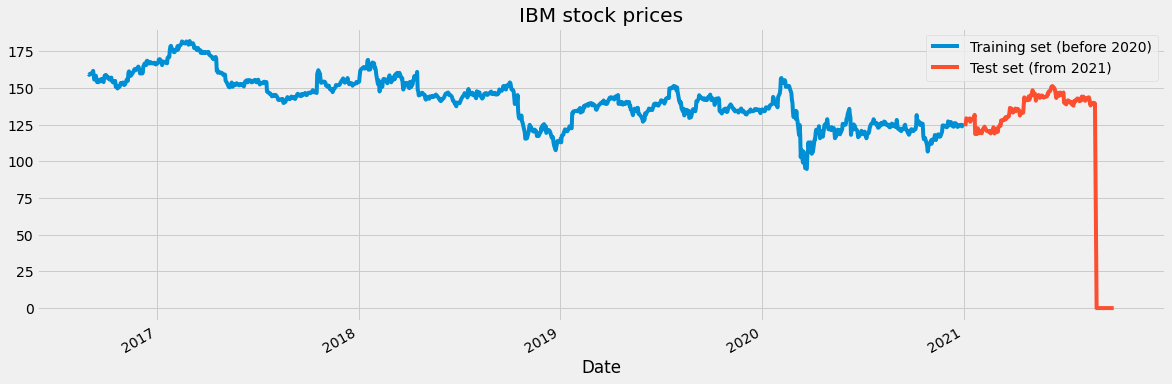

In [8]:
# visualization of "High" attribute of the dataset
data["Close"]["2015":"2020"].plot(figsize=(18,6), legend=True)
data["Close"]["2021":].plot(figsize=(18,6), legend=True)
plt.legend(["Training set (before 2020)", "Test set (from 2021)"])
plt.title("IBM stock prices")
plt.show()

In [9]:
# scaling the training set
sc = MinMaxScaler(feature_range=(0,1))
train_scaled = sc.fit_transform(train)

In [29]:
# Since LSTMs store long term memory state, we create a data structure with 60 timesteps and 1 output
# So for each element of training set, we have 60 previous training set elements
x_train = []
y_train = []

for i in range(60,len(train_scaled)):
    x_train.append(train_scaled[i-60:i, 0])
    y_train.append(train_scaled[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [30]:
x_train[0]

array([0.73380364, 0.72804244, 0.72757202, 0.73874207, 0.74215175,
       0.7527337 , 0.74626705, 0.71322751, 0.71475608, 0.70770133,
       0.68348031, 0.68888898, 0.67795414, 0.68724289, 0.6917109 ,
       0.68124631, 0.6993534 , 0.68547911, 0.66690197, 0.69406243,
       0.71593193, 0.79082899, 0.73015875, 0.71287479, 0.71475608,
       0.70652566, 0.70182244, 0.70499709, 0.71428584, 0.69617875,
       0.67289837, 0.66408003, 0.67948271, 0.68371551, 0.62621993,
       0.64326869, 0.64855966, 0.62798353, 0.63233403, 0.62810122,
       0.64903007, 0.66219875, 0.66666675, 0.6653734 , 0.66043515,
       0.65385081, 0.65843634, 0.65726049, 0.68630225, 0.68418575,
       0.67983543, 0.74567913, 0.74779543, 0.75390954, 0.72204585,
       0.72674907, 0.73121692, 0.74050566, 0.76731341, 0.76731341])

In [31]:
y_train[0]

0.7600236425645881

In [32]:
len(x_train)

1033

In [33]:
len(y_train)

1033

In [34]:
x_train.shape

(1033, 60)

In [35]:
y_train.shape

(1033,)

In [36]:
# reshaping x_train for efficient modelling
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [37]:
x_train.shape

(1033, 60, 1)

In [38]:
# LSTM architecture
regressor = Sequential()
# add first layer with dropout
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1],1)))
regressor.add(Dropout(0.2))
# add second layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# add third layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))
# add fourth layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
# the output layer
regressor.add(Dense(units=1))

In [39]:
# compiling the LSTM RNN network
regressor.compile(optimizer="rmsprop", loss="mean_squared_error")
# fit to the training set
regressor.fit(x_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
33/33 [==============================] - 5s 44ms/step - loss: 0.0411
Epoch 2/5
33/33 [==============================] - 1s 45ms/step - loss: 0.0199
Epoch 3/5
33/33 [==============================] - 1s 45ms/step - loss: 0.0182
Epoch 4/5
33/33 [==============================] - 1s 44ms/step - loss: 0.0156
Epoch 5/5
33/33 [==============================] - 1s 44ms/step - loss: 0.0146


In [50]:
# Now to get the test set ready in a similar way as the training set.
# The following has been done so forst 60 entires of test set have 60 previous values which is impossible to get unless we take the whole 'High' attribute data for processing
dataset_total = pd.concat((data["Close"]["2015":"2020"], data["Close"]["2021":]), axis=0)
print(dataset_total.shape)

inputs = dataset_total[len(dataset_total)-len(test)-60 : ].values
print(inputs.shape)
inputs = inputs.reshape(-1,1)
print(inputs.shape)
inputs = sc.transform(inputs)
print(inputs.shape)

(1282,)
(249,)
(249, 1)
(249, 1)
249


In [51]:
# preparing x_test
x_test = []
for i in range(60,inputs.shape[0]):
    x_test.append(inputs[i-60:i, 0])
    
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [52]:
# predicting the stock prices for test set
predicted = regressor.predict(x_test)
predicted = sc.inverse_transform(predicted)

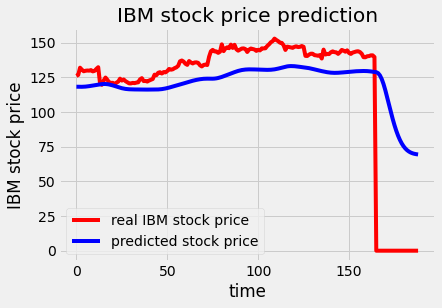

In [53]:
# visualizing the results: predicted vs test
plot_predictions(test, predicted)

In [54]:
# evaluating the model
return_rmse(test, predicted)

the root mean squared error is : 35.91012676084525.


In [55]:
# The GRU architecture
regressorGRU = Sequential()
# First GRU layer with Dropout regularisation
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(x_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Second GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(x_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Third GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(x_train.shape[1],1), activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Fourth GRU layer
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# The output layer
regressorGRU.add(Dense(units=1))

In [56]:
from tensorflow.keras.optimizers import SGD
# compiling the model
regressorGRU.compile(optimizer=SGD(lr=0.01, decay=1e-7, momentum=0.9, nesterov=False), loss='mean_squared_error')
# fitting the model
regressorGRU.fit(x_train, y_train, epochs=5, batch_size=150)

Epoch 1/5
7/7 [==============================] - 4s 117ms/step - loss: 0.1358
Epoch 2/5
7/7 [==============================] - 1s 116ms/step - loss: 0.0847
Epoch 3/5
7/7 [==============================] - 1s 113ms/step - loss: 0.0535
Epoch 4/5
7/7 [==============================] - 1s 115ms/step - loss: 0.0348
Epoch 5/5
7/7 [==============================] - 1s 116ms/step - loss: 0.0368


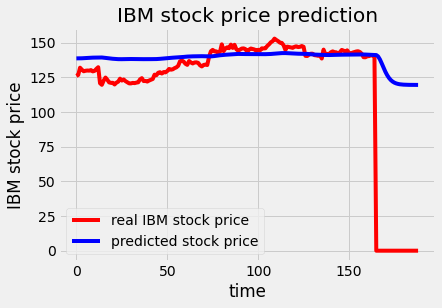

In [57]:
# predicting the stock prices for test set and visualization
predicted_with_gru = regressorGRU.predict(x_test)
predicted_with_gru = sc.inverse_transform(predicted_with_gru)
plot_predictions(test, predicted_with_gru)

In [58]:
# evaluating the model performance
return_rmse(test, predicted_with_gru)

the root mean squared error is : 45.16239813118788.
